# Where is the tech gap largest?

**Business question:** Technology help is one of the things that sets me apart. How many older adults have no computer or no internet at home, where are they, and can households there afford my rate?

**Why it matters:** It tells me which kind of tech help to pitch where. Getting someone online for the first time is a different job from helping someone use the phone, tablet or computer they already own.

**Data:** `data/census_by_zip.csv`, built by notebook 00 from the Census American Community Survey (ACS) 2020-2024.

**How to run:** Run the cells top to bottom. No Census key needed.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 220)

DATA = "../data/census_by_zip.csv"
if not os.path.exists(DATA):
    raise FileNotFoundError("Run notebook 00_get_data first. It creates data/census_by_zip.csv.")
table = pd.read_csv(DATA, dtype={"zip": str}).set_index("zip")
print(table.shape[0], "ZIP code areas loaded")

24 ZIP code areas loaded


## 1. Settings you can change

**INCOME_LINE** is the household income at which a weekly visit is comfortable. It comes from notebook 05: one 4-hour visit a week at &#36;35 an hour, costing up to 12% of income.

In [2]:
RATE, MIN_HOURS, BUDGET_SHARE = 35, 4, 0.12
INCOME_LINE = RATE * MIN_HOURS * 52 / BUDGET_SHARE
print(f"A weekly visit is comfortable at a household income of about ${INCOME_LINE:,.0f} or more.")

A weekly visit is comfortable at a household income of about $60,667 or more.


## 2. Count older adults who are offline at home

- **no_computer**: people 65+ living in a home with no computer. In this Census table a smartphone or tablet counts as a computer, so this means no device of any kind.
- **computer_no_internet**: people 65+ in a home that has a device but no internet subscription.
- **offline**: the two groups together.
- **connected**: people 65+ in a home with a device and broadband internet.
- **typical_household_income**: median income of all households headed by someone 65+ in the area. It describes the area, not offline households in particular.

In [3]:
t = table[["area"]].copy()
t["older_adults"] = table["tech65_total"]
t["no_computer"] = table["no_computer_65plus"]
t["computer_no_internet"] = table["computer_no_internet_65plus"]
t["offline"] = t["no_computer"] + t["computer_no_internet"]
t["share_offline"] = t["offline"] / t["older_adults"]
t["connected"] = table["broadband_65plus"]
t["typical_household_income"] = table["median_income_65plus_hh"]
t["can_likely_pay"] = t["typical_household_income"] >= INCOME_LINE
t = t.sort_values("offline", ascending=False)
t.round(2)

,area,older_adults,no_computer,computer_no_internet,offline,share_offline,connected,typical_household_income,can_likely_pay
zip,,,,,,,,,
94501,"Alameda, main island",10213,799,380,1179,0.12,8997,69740,True
94607,"Oakland, West Oakland / Chinatown",3756,681,442,1123,0.30,2624,24362,False
94601,"Oakland, Fruitvale",6300,728,372,1100,0.17,5200,41107,False
94606,"Oakland, San Antonio / Eastlake",5268,645,443,1088,0.21,4157,33565,False
94605,"Oakland, East Oakland hills",6955,368,489,857,0.12,6066,84621,True
94603,"Oakland, Elmhurst",3351,408,416,824,0.25,2527,53648,False
94602,"Oakland, Glenview / Dimond",5793,491,212,703,0.12,5090,88351,True
94621,"Oakland, Coliseum area",2846,316,363,679,0.24,2155,35195,False
94612,"Oakland, downtown",3157,326,326,652,0.21,2505,19241,False


## 3. What the numbers say

The link score compares two rankings of the areas: by share of older adults who are offline, and by typical income. A score near -1 means the lower the income, the more people are offline.

In [4]:
total, everyone = t["offline"].sum(), t["older_adults"].sum()
print(f"{total:,.0f} people 65+ are offline at home: {total / everyone:.0%} of older adults, about 1 in {everyone / total:.0f}.")
print(f"   {t['no_computer'].sum():,.0f} have no device at all; {t['computer_no_internet'].sum():,.0f} have a device but no internet.")
print(f"{t['connected'].sum():,.0f} ({t['connected'].sum() / everyone:.0%}) have a device and broadband.")
link = t["share_offline"].rank().corr(t["typical_household_income"].rank())
print(f"Link between being offline and income: {link:.2f}")

tight, pay = t[~t["can_likely_pay"]], t[t["can_likely_pay"]]
print(f"{tight['offline'].sum() / total:.0%} of offline older adults live in areas where the typical income is below the line.\n")

print(f"In the {len(pay)} areas where a weekly visit fits the typical income:")
print(f"   {pay['offline'].sum():,.0f} older adults are offline ({pay['offline'].sum() / pay['older_adults'].sum():.0%}).")
print(f"   {pay['connected'].sum():,.0f} are connected ({pay['connected'].sum() / pay['older_adults'].sum():.0%}).")
print("   Largest offline groups among these areas:")
for z, row in pay.head(6).iterrows():
    print(f"      {z}  {row['area']}: {row['offline']:,.0f} offline ({row['share_offline']:.0%})")

print(f"\nIn the {len(tight)} areas below the line, the largest offline groups:")
for z, row in tight.head(5).iterrows():
    print(f"      {z}  {row['area']}: {row['offline']:,.0f} offline ({row['share_offline']:.0%}), typical household income ${row['typical_household_income']:,.0f}")

12,293 people 65+ are offline at home: 12% of older adults, about 1 in 8.
   6,999 have no device at all; 5,294 have a device but no internet.
87,549 (88%) have a device and broadband.
Link between being offline and income: -0.83
52% of offline older adults live in areas where the typical income is below the line.

In the 16 areas where a weekly visit fits the typical income:
   5,897 older adults are offline (9%).
   62,638 are connected (91%).
   Largest offline groups among these areas:
      94501  Alameda, main island: 1,179 offline (12%)
      94605  Oakland, East Oakland hills: 857 offline (12%)
      94602  Oakland, Glenview / Dimond: 703 offline (12%)
      94610  Oakland, Grand Lake: 613 offline (11%)
      94611  Oakland, Montclair / Piedmont: 518 offline (6%)
      94619  Oakland, Laurel / Redwood Heights: 407 offline (10%)

In the 8 areas below the line, the largest offline groups:
      94607  Oakland, West Oakland / Chinatown: 1,123 offline (30%), typical household incom

## 4. Chart: the ten areas with the most older adults offline at home

Each bar is the number of people 65+ with no computer or no internet at home; the percent is their share of the area's older adults. Dark bars are areas where a weekly visit fits the typical income. The column on the right is that typical income.

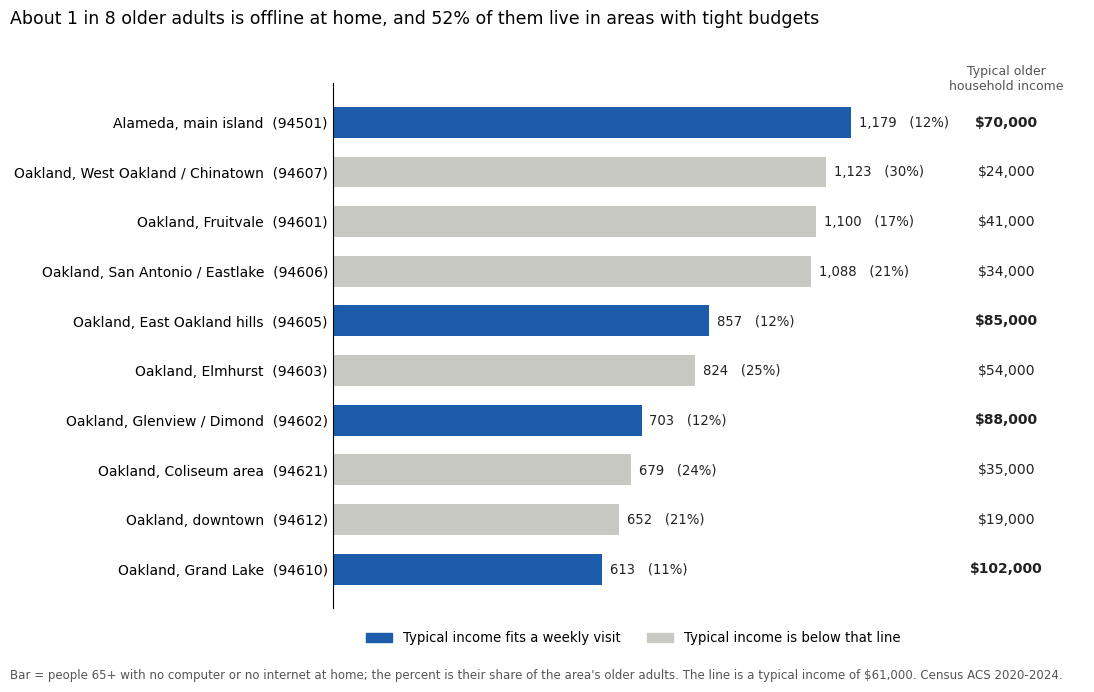

In [5]:
OUT = "../outputs"
os.makedirs(OUT, exist_ok=True)

show = t.head(10)
ypos = list(range(len(show)))[::-1]   # first row at the top
labels = [f"{row['area']}  ({z})" for z, row in show.iterrows()]
DARK, GRAY = "#1c5cab", "#c9c9c4"

fig, ax = plt.subplots(figsize=(11, 0.45 * len(show) + 2.4))
ax.barh(ypos, show["offline"], color=[DARK if c else GRAY for c in show["can_likely_pay"]], height=0.62)
longest = show["offline"].max()
col_x = longest * 1.3
for y, (z, row) in zip(ypos, show.iterrows()):
    ax.text(row["offline"] + longest * 0.015, y, f"{row['offline']:,.0f}   ({row['share_offline']:.0%})",
            va="center", fontsize=9.5, color="#222222")
    ax.text(col_x, y, f"\\${round(row['typical_household_income'], -3):,.0f}", va="center", ha="center", fontsize=10,
            color="#222222", fontweight="bold" if row["can_likely_pay"] else "normal")
ax.text(col_x, len(show) - 0.4, "Typical older\nhousehold income", va="bottom", ha="center", fontsize=9, color="#555555")
ax.set_yticks(ypos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(0, longest * 1.45)
ax.set_xticks([])
ax.tick_params(axis="y", length=0)
for side in ["top", "right", "bottom"]:
    ax.spines[side].set_visible(False)
handles = [plt.Rectangle((0, 0), 1, 1, color=DARK), plt.Rectangle((0, 0), 1, 1, color=GRAY)]
ax.legend(handles, ["Typical income fits a weekly visit", "Typical income is below that line"],
          loc="upper center", bbox_to_anchor=(0.4, -0.02), ncol=2, frameon=False, fontsize=9.5)
fig.suptitle(f"About 1 in {everyone / total:.0f} older adults is offline at home, and {tight['offline'].sum() / total:.0%} of them live in areas with tight budgets",
             x=0.01, ha="left", fontsize=12.5)
fig.text(0.01, 0.01, f"Bar = people 65+ with no computer or no internet at home; the percent is their share of the area's older adults. "
         f"The line is a typical income of \\${round(INCOME_LINE, -3):,.0f}. Census ACS 2020-2024.", fontsize=8.5, color="#555555")
plt.tight_layout(rect=(0, 0.03, 1, 0.97))
fig.savefig(f"{OUT}/tech_gap.png", dpi=150)
t.round(3).to_csv(f"{OUT}/tech_gap.csv")
plt.show()

## 5. What I decided

- **Where to pitch "getting online":** the offline groups in Alameda's main island, the East Oakland hills, Glenview / Dimond and Grand Lake.
- **Where to pitch "help with the devices you already have":** all the areas that can pay, where about 91% of older adults already have a device and broadband.
- **How much weight tech help gets in my marketing:** It is a main selling point. None of the 15 agency pages in notebook 10 advertise it.

### Limits to remember
- The Census counts whether a home has a device and internet. It does not measure whether the older adult can use them, which is the need I would mostly be serving.
- The numbers are people in households, so nursing home residents are left out.
- Income here describes all older households in an area, not offline households in particular. Offline households likely earn less than the area's typical household.
- ZIP-code estimates are survey-based. Treat close numbers as ties.